In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

In [3]:
actions_per_user_df = pd.read_csv(r"C:\Users\danil\Desktop\metrix\pet_project\superset\actions_per_user.csv")

actions_per_user_df = actions_per_user_df.sort_values('start_date')
control_dates = ['2025-11-06', '2025-11-13', '2025-11-20', '2025-11-27']

df_control = actions_per_user_df[actions_per_user_df['start_date'].isin(control_dates)].copy()
df_test = actions_per_user_df[actions_per_user_df['start_date'] == '2025-12-04'].copy()

df_control_2025_11_06 = df_control.loc[df_control['start_date'] == '2025-11-06', ['likes', 'views', 'ctr', 'age']]
df_control_2025_11_13 = df_control.loc[df_control['start_date'] == '2025-11-13', ['likes', 'views', 'ctr', 'age']]
df_control_2025_11_20 = df_control.loc[df_control['start_date'] == '2025-11-20', ['likes', 'views', 'ctr', 'age']]
df_control_2025_11_27 = df_control.loc[df_control['start_date'] == '2025-11-27', ['likes', 'views', 'ctr', 'age']]

ctrl_days = {
    '2025-11-06': df_control_2025_11_06,
    '2025-11-13': df_control_2025_11_13,
    '2025-11-20': df_control_2025_11_20,
    '2025-11-27': df_control_2025_11_27
}

Для начала посмотрим на наши данные визульно а также посмотрим, достаточно ли у нас пользователей в каждой из групп для проведения А/Б-теста

In [4]:
print('Число пользователей в контрольной группе =', len(df_control))
print('Число пользователей в тествой группе =', len(df_test))

for control_day, values in ctrl_days.items():
    print(f'Число пользователей в контрольном дне {control_day} = ', len(values))

Число пользователей в контрольной группе = 2871
Число пользователей в тествой группе = 2238
Число пользователей в контрольном дне 2025-11-06 =  917
Число пользователей в контрольном дне 2025-11-13 =  772
Число пользователей в контрольном дне 2025-11-20 =  804
Число пользователей в контрольном дне 2025-11-27 =  378


Как мы видим пользователей обоих групп достаточно для проведения А/Б-теста

Теперь посмотрим на наши данные через боксплот

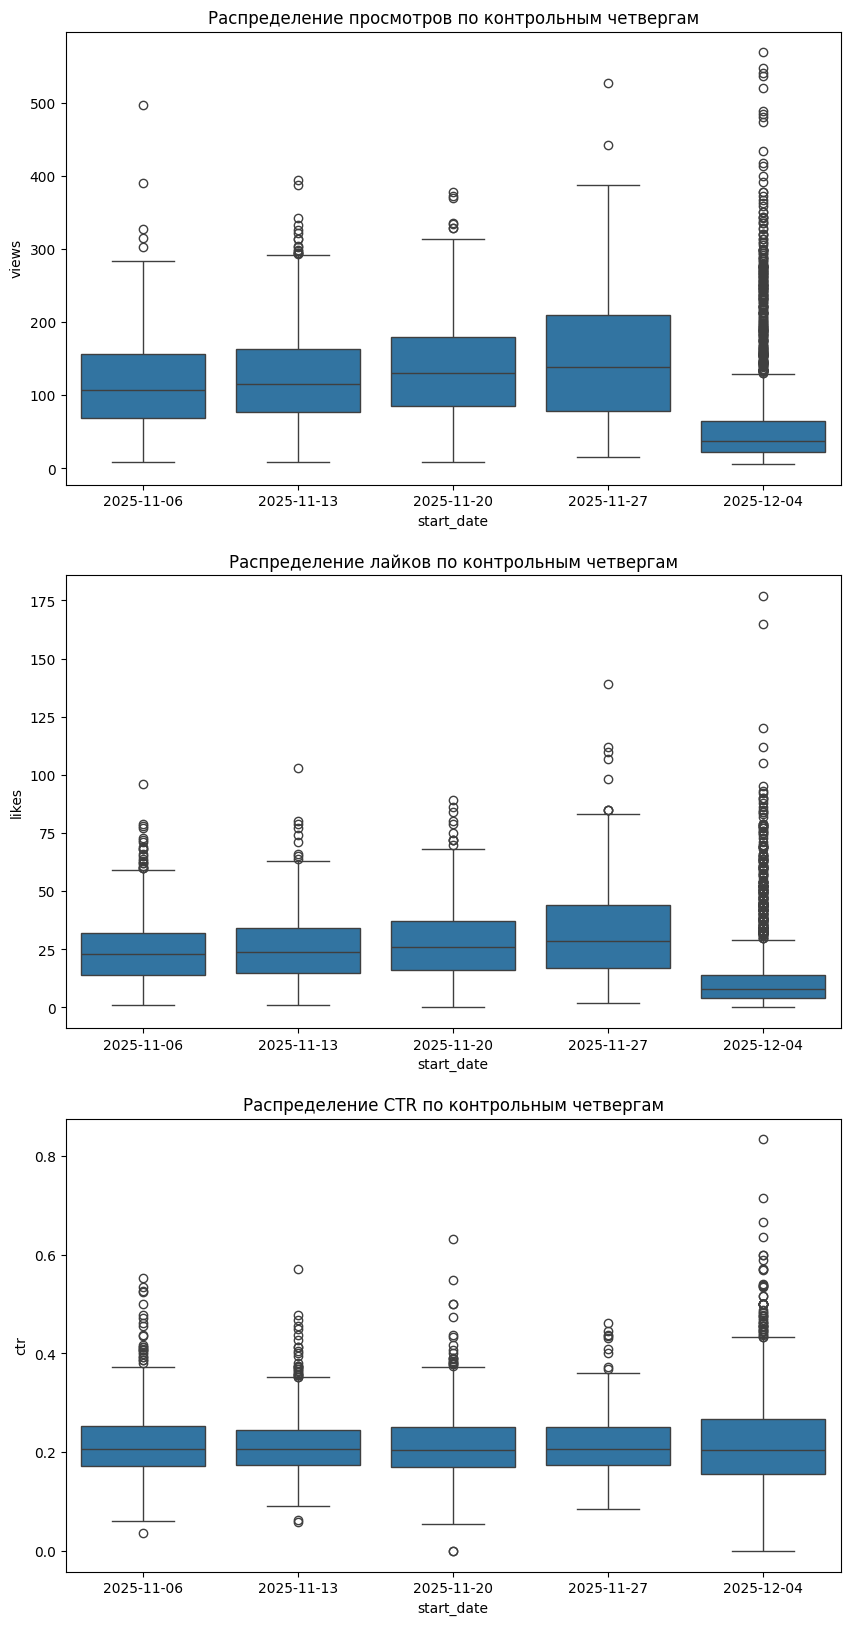

In [5]:
plt.figure(figsize= (10,20))
plt.subplot(3, 1, 1)
sns.boxplot(x='start_date', y='views', data=actions_per_user_df)
plt.title('Распределение просмотров по контрольным четвергам')

plt.subplot(3, 1, 2)
sns.boxplot(x='start_date', y='likes', data=actions_per_user_df)
plt.title('Распределение лайков по контрольным четвергам')

plt.subplot(3, 1, 3)
sns.boxplot(x='start_date', y='ctr', data=actions_per_user_df)
plt.title('Распределение CTR по контрольным четвергам')

plt.show()

По боксплоту видно, что разброс данных тестового дня значительно ниже разброса контрольных дней по метрикам likes и views как и его медианное значение, выбросов же сильно больше. Это согласуется с тем, что абсолютное большинство пользователей ушло после первого дня использования нашего приложения, потому значения с 1 по 3 квартиль слабо отличаюся друг от друга и собраны более компактно. Те же пользователи, которые использовали наш продукт и дальше стали выбросами и вышли за границы 1.5 * IQR. Медиана по метрика CTR же менее отличается, однако разброс у нее явно больше. При малом количестве просмотров и лайков мы будем иметь более большой разброс в данных по этой метрике, так что данные с поледнего графика согласуются с данными 2-х предыдущих.

### А/А тест для проверки ковариатов (пол, возраст, os)

Для начала попарно проверим возраст между днями с помощью теста Уэлча, применив поправку на множественную проверку гототез Холма

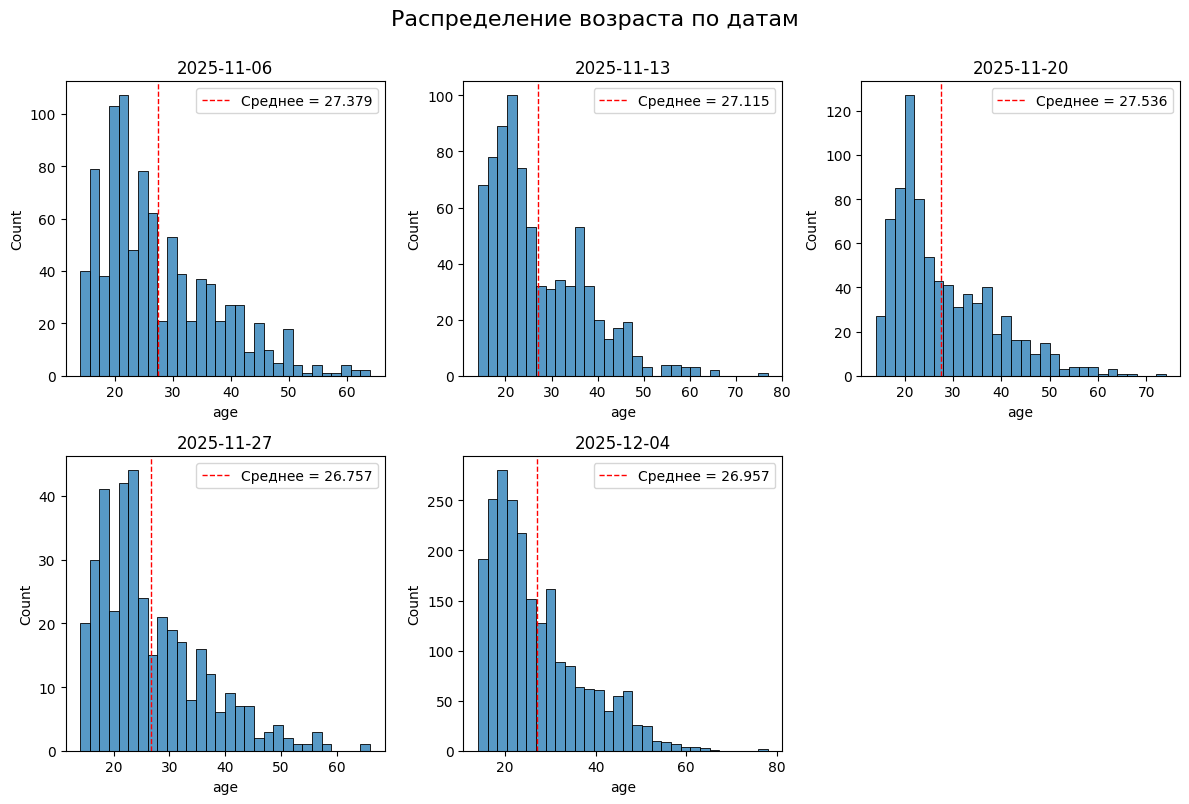

In [6]:
all_days = ctrl_days.copy()
all_days['2025-12-04'] = df_test

plt.figure(figsize=(12, 8))
plt.suptitle('Распределение возраста по датам', fontsize=16, y=1)

for i, (day, value) in enumerate(all_days.items(), start=1):
    mean_age = value['age'].mean()                      
    plt.subplot(2, 3, i)                             
    sns.histplot(value['age'], bins=30)                 
    plt.title(day)                                  
    plt.axvline(mean_age, color='red', linestyle='--', linewidth=1,
                label=f'Среднее = {mean_age:.3f}')
    plt.legend()

plt.tight_layout()
plt.show()

In [7]:
results = []
for (day1, data1), (day2, data2) in combinations(all_days.items(), 2):
    t_stat, p_val = stats.ttest_ind(data1['age'], data2['age'], equal_var=False)
    mean1 = data1['age'].mean()
    mean2 = data2['age'].mean()
    diff = mean1 - mean2
    results.append({
        'day1': day1,
        'day2': day2,
        'mean1': mean1,
        'mean2': mean2,
        'diff': diff,
        't_stat': t_stat,
        'p_value': p_val
    })

results_df = pd.DataFrame(results)


print("P-значения:")
print(results_df[['day1', 'day2', 'p_value']], '\n')


reject, p_corrected, _, _ = multipletests(results_df['p_value'], alpha=0.05, method='holm')

print(reject)

P-значения:
         day1        day2   p_value
0  2025-11-06  2025-11-13  0.588523
1  2025-11-06  2025-11-20  0.749148
2  2025-11-06  2025-11-27  0.288211
3  2025-11-06  2025-12-04  0.276716
4  2025-11-13  2025-11-20  0.416481
5  2025-11-13  2025-11-27  0.556567
6  2025-11-13  2025-12-04  0.708611
7  2025-11-20  2025-11-27  0.202276
8  2025-11-20  2025-12-04  0.172954
9  2025-11-27  2025-12-04  0.706955 

[False False False False False False False False False False]


Видим, что ни одна из скорректированных p-value не опустилась ниже 0.05 что нам и нужно, то есть дни по возрасту однородны. Проверим, есть ли разница между соотношениями полов и os по дате или нет с помошью хи^2 и таблицы сопряженности

In [8]:
contingency_sex = pd.crosstab(actions_per_user_df['start_date'], actions_per_user_df['gender']) # создаем частотную таблицу
chi2, p_global_sex, dof, expected = stats.chi2_contingency(contingency_sex)
print(f"Глобальный тест для пола: p = {p_global_sex:.3f}")

Глобальный тест для пола: p = 0.358


In [9]:
contingency_os = pd.crosstab(actions_per_user_df['start_date'], actions_per_user_df['os'])
chi2, p_global_sex, dof, expected = stats.chi2_contingency(contingency_os)
print(f"Глобальный тест для os: p = {p_global_sex:.3f}")

Глобальный тест для os: p = 0.221


Для обоих случаев p-value > 0.05. Таким образом из проверки по ковариатам можно сделать вывод, что тестовая и контрольные группы однородны и их можно брать для дальнейшего А/Б

### A/A Тест для проверки репрезентативности по метрикам likes, views, CTR

Проведем попарные тесты для того, чтобы выяснить, есть ли различия в средних в наших днях и можно ли их объединить в одну контрольную группу. Для начала сделаем это с CTR.

Однако в данном случае к поюзерному CTR нужен особый подход, так как это retio-метрика. Проблема в том, что если просто усреднить персональные CTR по пользователям, то пользователи с малым числом просмотров получат такой же вес, как и пользователи с большим числом просмотров, хотя их вклад в общий CTR (сумма лайков / сумма просмотров) несопоставим.
Чтобы корректно сравнить CTR между днями, используем общегрупповой CTR (сумма лайков в выборке / сумма просмотров в выборке).

In [10]:
def bootstrap_group_ctr_diff(df, n_bootstrap=3000):
    '''
    Функция для подсчета групповго CTR. Возвращает numpy-массив из суммы лайков в выборке / сумму просмотров
    '''
   
    n_users = len(df)
    boot_ctrs = np.empty(n_bootstrap)
    
    for i in range(n_bootstrap):
        
        sample = df.sample(n=n_users, replace=True)
        total_likes = sample['likes'].sum()
        total_views = sample['views'].sum()
        boot_ctrs[i] = total_likes / total_views
    
    return boot_ctrs

In [11]:
def bootstrap_dict(diff, day1, day2):
    '''
    Также применим эти функции для создания словаря со значениями попарных сравнений дней при использовании бутстрапа
    '''
    p_value = 2 * min(np.mean(diff > 0), np.mean(diff < 0))
    ci_low = np.percentile(diff, 2.5) 
    ci_high = np.percentile(diff, 97.5)
    
    dict_days ={
        'day1': day1,
        'day2': day2,
        'p_value': p_value,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'diff_mean': np.mean(diff),
        'diff': diff 
    }
    
    return dict_days

Применим эту функцию и рассчитаем для каждой пары контрольных дней среднее, p-value и доверительный интервал

In [12]:
results = []

for day1, day2 in combinations(ctrl_days, 2):
    
    boot1 = bootstrap_group_ctr_diff(ctrl_days[day1])
    boot2 = bootstrap_group_ctr_diff(ctrl_days[day2])
    diff = boot1 - boot2
    dict_days = bootstrap_dict(diff, day1, day2)
    results.append(dict_days)
    
results_df = pd.DataFrame(results)
print(results_df[['day1', 'day2', 'diff_mean', 'ci_low', 'ci_high', 'p_value']].sort_values('day1'))

         day1        day2  diff_mean    ci_low   ci_high   p_value
0  2025-11-06  2025-11-13   0.002313 -0.003391  0.007918  0.422000
1  2025-11-06  2025-11-20   0.002990 -0.002922  0.008918  0.320000
2  2025-11-06  2025-11-27  -0.001674 -0.009801  0.006320  0.692667
3  2025-11-13  2025-11-20   0.000638 -0.005109  0.006100  0.837333
4  2025-11-13  2025-11-27  -0.003927 -0.011503  0.003472  0.309333
5  2025-11-20  2025-11-27  -0.004515 -0.012560  0.003496  0.270667


Напишем функцию для построения бутстреп-разности средних, чтобы не будлировать код в дальнейшем

In [13]:
def plot_bootstrap_comparisons(results, metric_name='', xlabel='Разность средних', 
                               suptitle='Сравнение метрики', cols=3, figsize=(15, 10)):
    """
    Строит гистограммы бутстреп-распределений разности средних для списка результатов.

    Параметры:
    results : list of dict
        Каждый словарь должен содержать ключи: 'day1', 'day2', 'diff', 'p_value', 'ci_low', 'ci_high', 'diff_mean'
    metric_name : str
        Название метрики (добавляется в заголовок каждого подграфика)
    xlabel : str
        Подпись оси X
    suptitle : str
        Общий заголовок фигуры
    cols : int
        Количество столбцов в сетке подграфиков
    figsize : tuple
        Размер фигуры
    """
    n = len(results)
    rows = (n + cols - 1) // cols               # количество строк
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:                               # если одна строка, axes не является списком
        axes = [axes]
    axes = axes.flatten()

    for idx, res in enumerate(results):
        ax = axes[idx]
        diff = res['diff']

        # Гистограмма
        ax.hist(diff, bins=30, alpha=0.7, color='skyblue', edgecolor='black')

        # Линии: нулевая и доверительный интервал
        ax.axvline(0, color='red', linestyle='--', linewidth=2)
        ax.axvline(res['ci_low'], color='blue', linestyle=':', linewidth=2)
        ax.axvline(res['ci_high'], color='blue', linestyle=':', linewidth=2)

        # Легенда
        legend_elements = [
            Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='0 (нет эффекта)'),
            Line2D([0], [0], color='blue', linestyle=':', linewidth=2, label='95% ДИ')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

        # Текстовая информация (p-value, среднее)
        textstr = f"p-value = {res['p_value']:.3f}\nСреднее = {res['diff_mean']:.3f}"
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        # Заголовок и подписи осей
        title = f"{res['day1']} vs {res['day2']}"
        if metric_name:
            title += f" ({metric_name})"
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Частота')
        ax.tick_params(axis='x', rotation=45)

    # Скрыть лишние подграфики (если мест больше, чем результатов)
    for j in range(len(results), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(suptitle, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

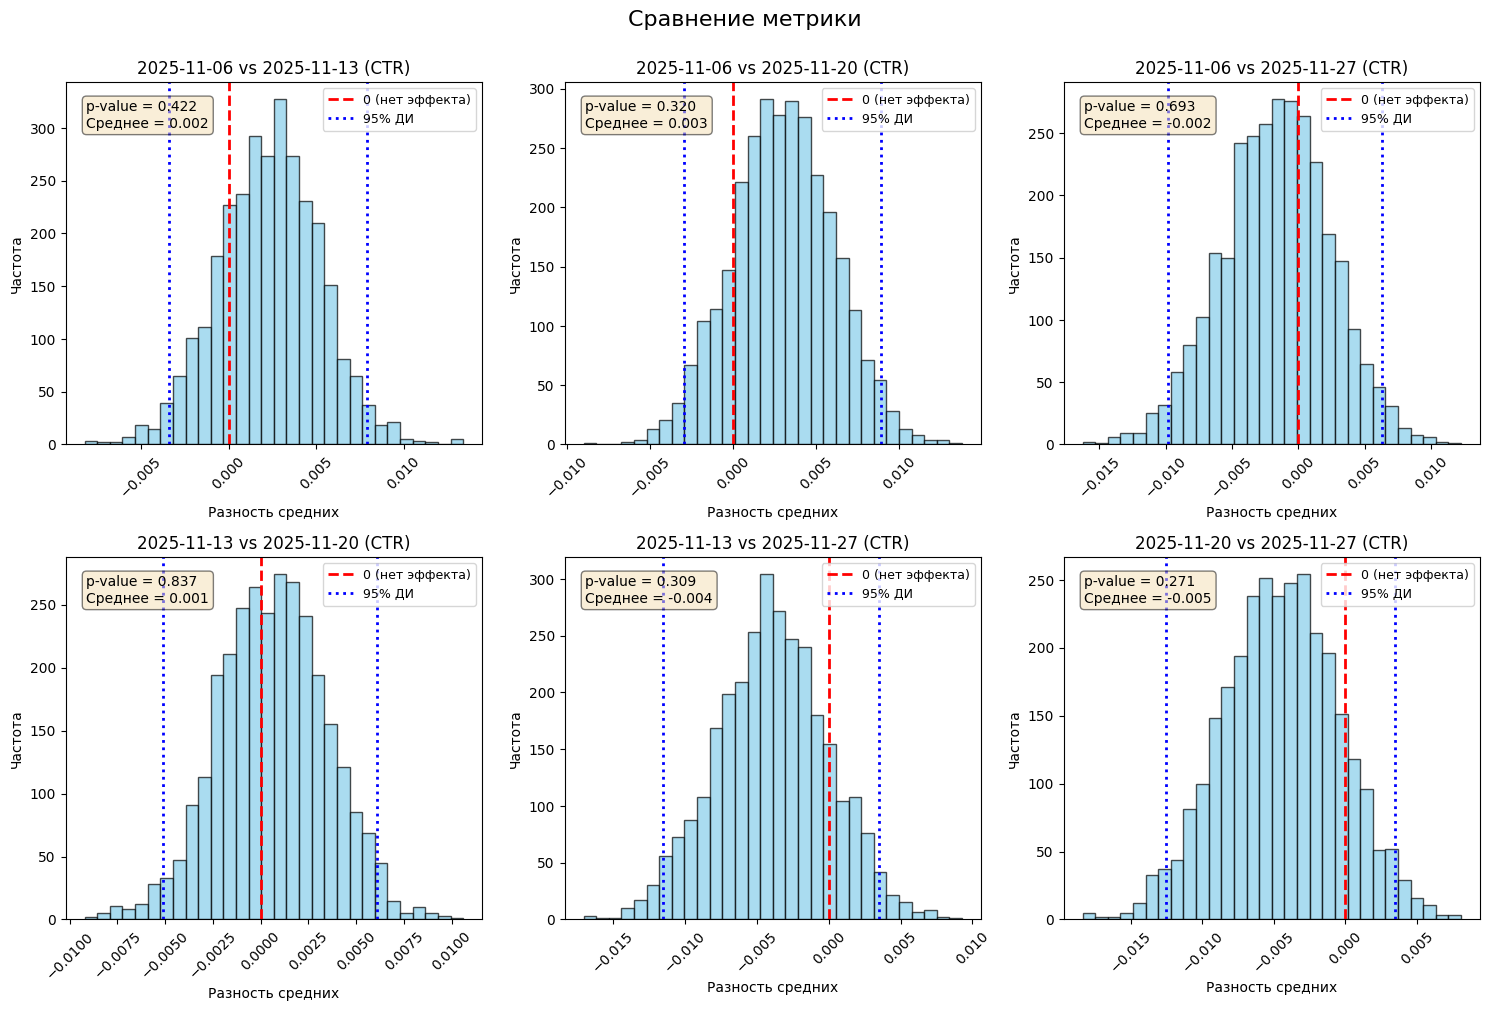

In [14]:
plot_bootstrap_comparisons(results, 'CTR')

А также сделаем коррекцию Холма.

In [15]:
reject, p_corrected, _, _ = multipletests(results_df['p_value'], alpha=0.05, method='holm')

print(reject)

[False False False False False False]


Сделав коррекцию на множественные сравнения Холма мы видим, что у нас везде False. Значит можно сделать вывод что, уже с поправкой, дни значимо не различаются между собой, значит им можно объединить в одну контрольную группу для сравнения с тестовым днем для метрики CTR. А что по просмотрам и лайкам? Напишем функцию, которая попарно сравнивает контрольные дни между собой по этим метрикам

In [16]:
def pair_compare(data, metric):
    '''
    На вход подаем датафрейм и колонку с метрикой, а на выходе получаем попарные сравнения дней и отсортированные по возрастанию значениям метрики 
    '''

    thursdays = data['start_date'].unique()
    
    means_dict = {}
    p_values = []
    compares = ''
    
    for day in thursdays:
        means_dict[day] = round(np.mean(data.loc[data['start_date'] == day, metric]), 4)

    for day1, day2 in combinations(thursdays, 2):
        data1 = data[data['start_date'] == day1][metric]
        data2 = data[data['start_date'] == day2][metric]
        p = stats.ttest_ind(data1, data2, equal_var=False).pvalue
        p_values.append(p)
        compares += f"{day1} vs {day2}: p={p:.4f}\n"
    
    sorted_means = dict(sorted(means_dict.items(), key=lambda item: item[1]))
    
    return compares, sorted_means, p_values

Сравним дни по лайкам

In [17]:
compares, sorted_means, p_values = pair_compare(df_control, 'likes')

print('Попарное сравнение дней по количеству лайков на пользователя')
print(compares, '\n', 'Средние для каждого дня по возрастанию:\n', sorted_means, '\n\n')

Попарное сравнение дней по количеству лайков на пользователя
2025-11-06 vs 2025-11-13: p=0.0187
2025-11-06 vs 2025-11-20: p=0.0000
2025-11-06 vs 2025-11-27: p=0.0000
2025-11-13 vs 2025-11-20: p=0.0069
2025-11-13 vs 2025-11-27: p=0.0000
2025-11-20 vs 2025-11-27: p=0.0011
 
 Средние для каждого дня по возрастанию:
 {'2025-11-06': np.float64(24.5289), '2025-11-13': np.float64(26.1788), '2025-11-20': np.float64(28.24), '2025-11-27': np.float64(32.2354)} 




И по просмотрам

In [18]:
compares, sorted_means, p_values = pair_compare(df_control, 'views')

print('Попарное сравнение дней по количеству просмотров на пользователя')
print(compares, '\n', 'Средние для каждого дня по возрастанию:\n', sorted_means, '\n\n')

Попарное сравнение дней по количеству просмотров на пользователя
2025-11-06 vs 2025-11-13: p=0.0040
2025-11-06 vs 2025-11-20: p=0.0000
2025-11-06 vs 2025-11-27: p=0.0000
2025-11-13 vs 2025-11-20: p=0.0026
2025-11-13 vs 2025-11-27: p=0.0000
2025-11-20 vs 2025-11-27: p=0.0023
 
 Средние для каждого дня по возрастанию:
 {'2025-11-06': np.float64(115.5812), '2025-11-13': np.float64(124.7383), '2025-11-20': np.float64(134.9826), '2025-11-27': np.float64(150.7619)} 




Видим, что по этим метрикам контрольные дни ститистически значимо различаются между собой, причем метрики растут во времени. Обединять их по этим метрикам явно нельзя, нужно сравнивать каждый день с тестовым отдельно и потом на основе этой информации делать выводы

### Теперь проведем А/Б тест и узнаем, статистически ли значимо различаются метрики по CTR, просмотрам и лайкам у наших групп.

Сделаем это также с помощью бутстрапа. Сначала проверим групповой CTR и как наши пользователи из тестовой группы оценили алгоритмы предложения контента относительно предудущей кампании

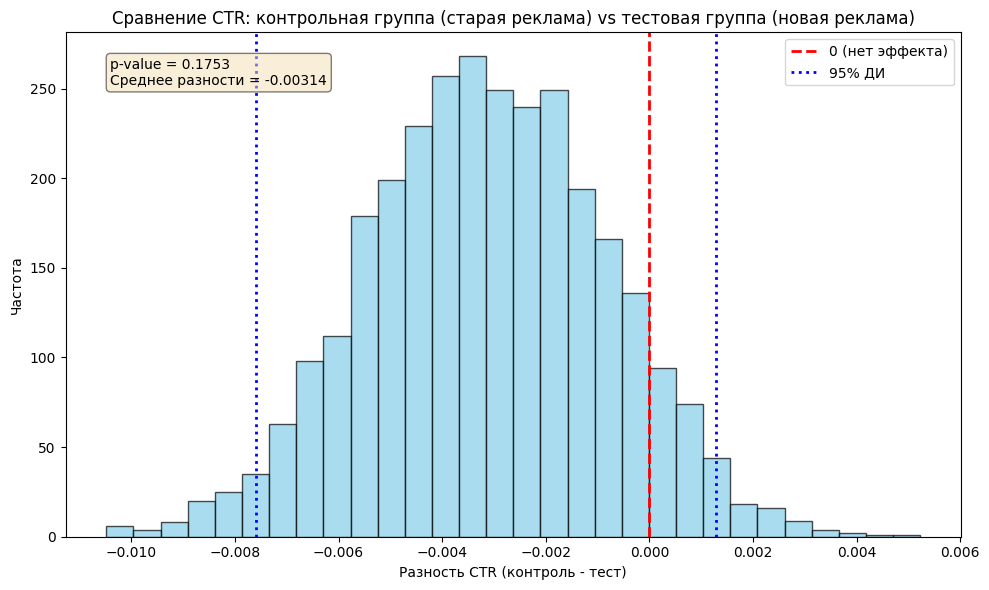

In [19]:
boot_ctr_day1 = bootstrap_group_ctr_diff(df_control)
boot_ctr_day2 = bootstrap_group_ctr_diff(df_test)

diff = boot_ctr_day1 - boot_ctr_day2
p_value = 2 * min(np.mean(diff>0), np.mean(diff<0))
ci_low = np.percentile(diff, 2.5)
ci_high = np.percentile(diff, 97.5)

fig, ax = plt.subplots(figsize=(10, 6))

# Гистограмма распределения разности
ax.hist(diff, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='0 (нет эффекта)')

# Доверительный интервал разности (2.5% и 97.5% процентили)

ax.axvline(ci_low, color='blue', linestyle=':', linewidth=2, label='95% ДИ')
ax.axvline(ci_high, color='blue', linestyle=':', linewidth=2)

# Подписи осей и заголовок
ax.set_title('Сравнение CTR: контрольная группа (старая реклама) vs тестовая группа (новая реклама)')
ax.set_xlabel('Разность CTR (контроль - тест)')
ax.set_ylabel('Частота')

# Текстовая информация на графике (p-value и средняя разность)
textstr = f"p-value = {p_value:.4f}\nСреднее разности = {np.mean(diff):.5f}"
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend()
plt.tight_layout()
plt.show()

Мы не получили статистически значимого результата, который позволил бы нам отклонить нулевую гипотезу о равенстве средних. Значит если принять, что главной метрикой наших алгоритмов является CTR, то вопрос об удовлетворенности нашими алгоритмами отпадает - мы не нашли убедительных доказательств в пользу того, что пользователи из тестовой группы ставят лайки чаще или меньше (вероятность в обеих группа около 0.2), чем пользователи из контрольной. Осталось выяснить, различаются ли группы по лайкам и просмотрам в абсолютных зачениях на пользователя и тогда можно переходить к выводам 

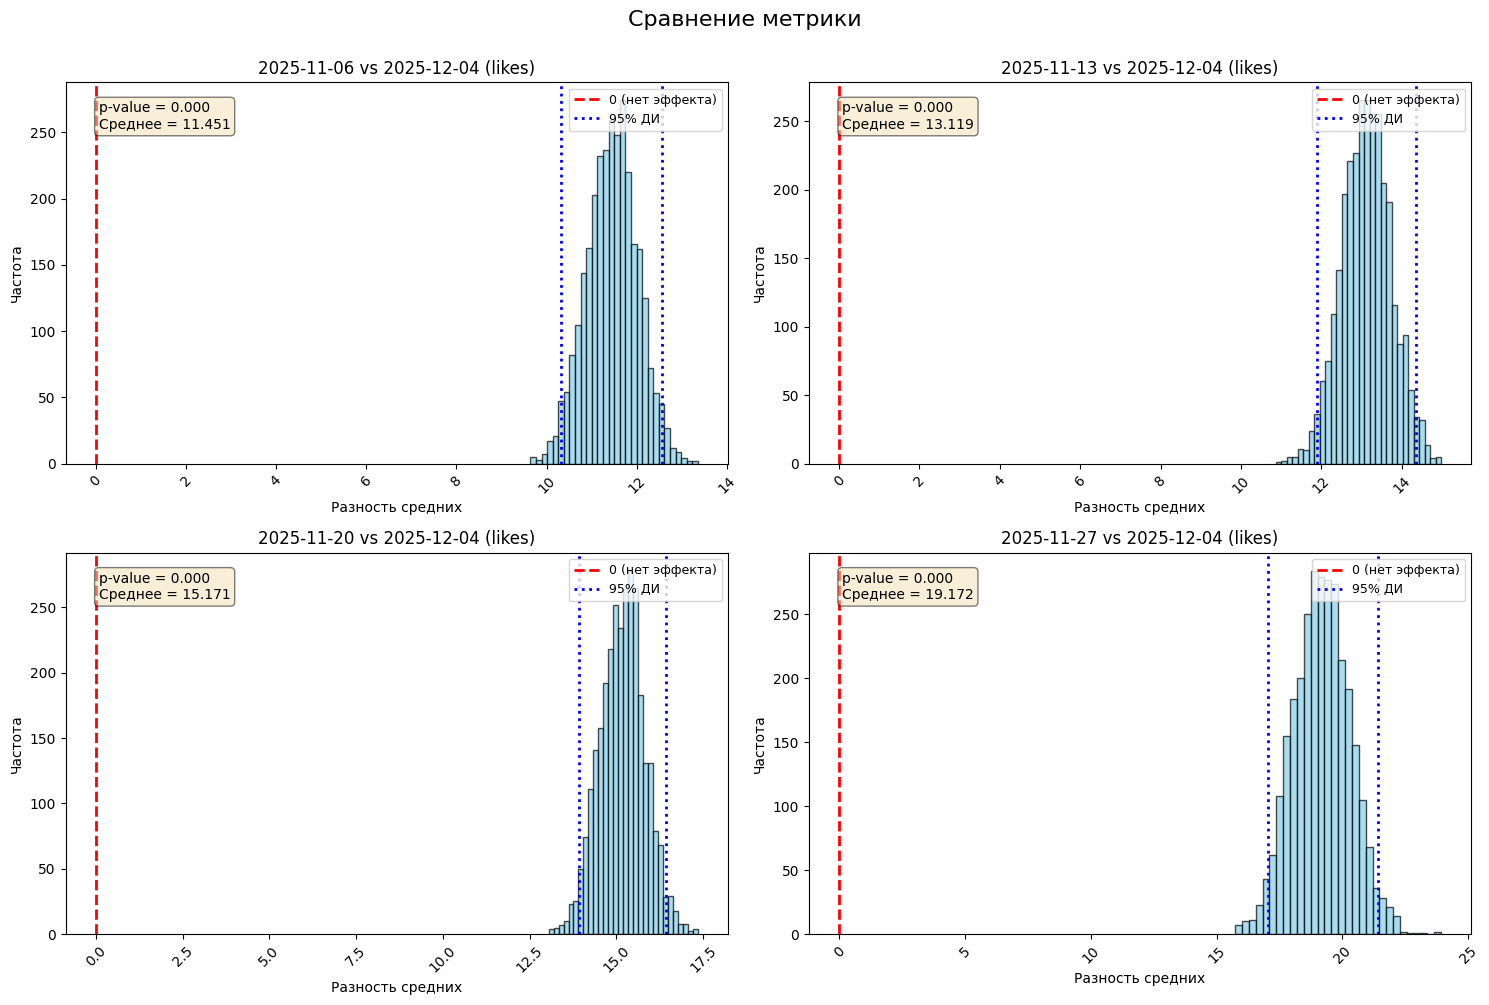

In [20]:
def bootstrap_mean_diff(data1, data2, n_bootstrap=3000):
    n1, n2 = len(data1), len(data2)
    diff = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=n1, replace=True)
        sample2 = np.random.choice(data2, size=n2, replace=True)
        diff[i] = np.mean(sample1) - np.mean(sample2)
    return diff

test_date = '2025-12-04'
results_likes = []

for day in ctrl_days:
    diff = bootstrap_mean_diff(ctrl_days[day]['likes'], df_test['likes'])
    likes_dict = bootstrap_dict(diff, day, test_date)
    results_likes.append(likes_dict)

plot_bootstrap_comparisons(results_likes, 'likes', cols=2)  

Лайки из тестовой группы ставят значимо реже. А что с просмотрами?

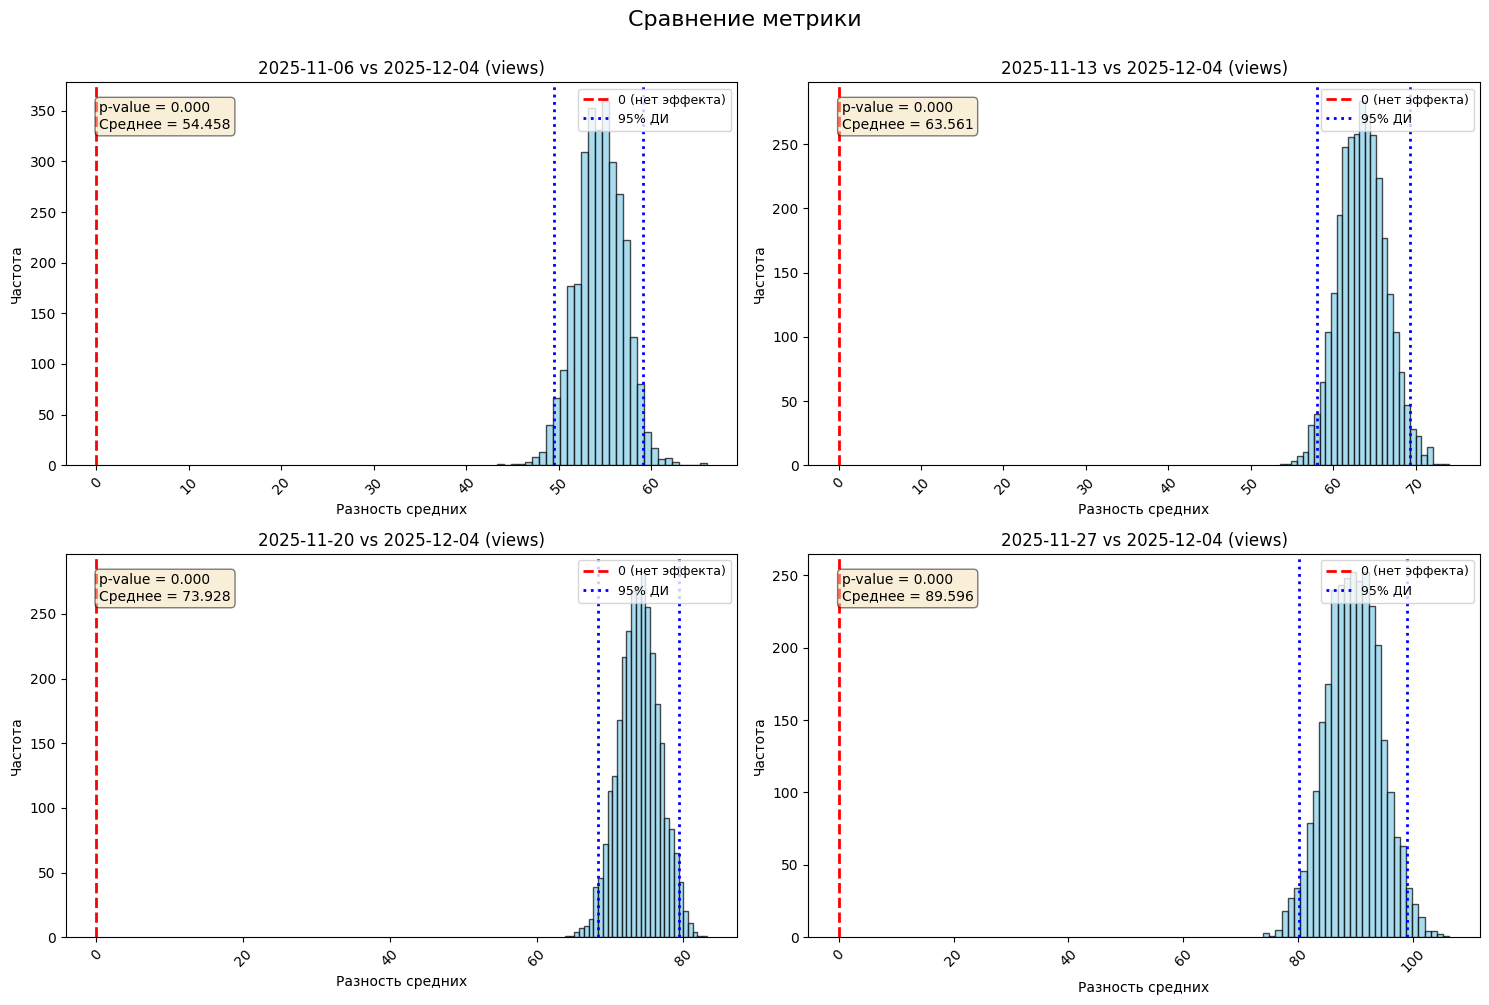

In [ ]:
results_views = []

for day in ctrl_days:
    diff = bootstrap_mean_diff(ctrl_days[day]['views'], df_test['views'])
    views_dict = bootstrap_dict(diff, day, test_date)
    results_views.append(views_dict)

plot_bootstrap_comparisons(results_views, 'views', cols=2)

Мы видим следующее:

1. Среди пользователей, привлечённых по старой рекламе, наблюдался статистически значимый рост абсолютной активности (лайков и просмотров) от четверга к четвергу.
2. Пользователи из тестовой группы (новая реклама) демонстрируют значимо более низкие значения лайков и просмотров по сравнению с каждым контрольным днём.
3. Удовлетворенность по метрике CTR между тестовой и контрольными группами статистически не различается. Значит, при просмотре поста новая аудитория с той же вероятностью ставит лайк, что и старая.

Новая рекламная кампания привлекла менее активных пользователей (по абсолютным показателям), но качество их взаимодействия с контентом (CTR) не уступает контрольной группе.
Таким образом, гипотеза о том, что отток мог быть вызван низкой оценкой контента, не подтверждается. Вероятные причины могут быть в области UX/UI, технических проблемах или в несоответствии аудитории продукту. Для проверки уже этих гипотез необходимы дополнительные данные и исследования